# Starting kit 

In [1]:
import sys

sys.path.append('/rds/rds-clecat/generative_modelling/STL_21')

from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass
from STL_main.ST_Operator import ST_Operator as SO
from STL_main.Synthesis import optimize_scattering_LBFGS

In [2]:
import os
import sys

path_STL= os.path.join(os.getcwd(), 'STL_21')

sys.path.append(path_STL)

In [3]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.fft
from importlib import reload
from functools import partial
import sys
import healpy as hp
import os

In [4]:
torch.cuda.is_available()

True

In [5]:
import glob
import numpy as np

files = glob.glob("tSZ_patches/*.npy")
patches = [np.load(f) for f in files]

print(f"{len(patches)} maps loaded")

# The maps need to be in float 64
for i in range(len(patches)):
    patches[i] = patches[i].astype(np.float64)

10 maps loaded


Visualize a patch

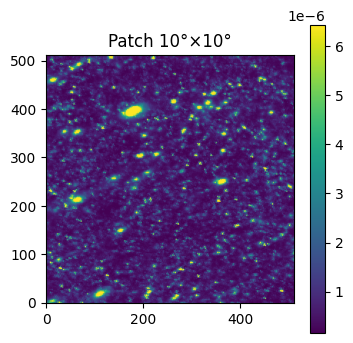

In [6]:
vmin, vmax = np.percentile(patches[0], [1, 99])

plt.figure(figsize=(4, 4))
im = plt.imshow(patches[0], vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar(im)
plt.title("Patch 10°×10°")
plt.show()

Synthesis parameters

In [7]:
patch = (patches[0] - np.mean(patches[0]))/np.std(patches[0])
target = patch
seed=10
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None

In [8]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=500,
        lr=1,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (1, 1, 512, 512)
Synthesis on 5880 ST coefficients
[LBFGS] inner iter 10, loss = 2.156550e+01
[LBFGS] inner iter 20, loss = 3.372608e+00
[LBFGS] inner iter 30, loss = 1.185750e+00
[LBFGS] inner iter 40, loss = 2.193137e-01
[LBFGS] inner iter 50, loss = 5.531374e-02
[LBFGS] inner iter 60, loss = 2.441501e-02
[LBFGS] inner iter 70, loss = 1.696795e-02
[LBFGS] inner iter 80, loss = 1.326460e-02
[LBFGS] inner iter 90, loss = 9.707737e-03
[LBFGS] inner iter 100, loss = 8.054311e-03
[LBFGS] inner iter 110, loss = 7.011231e-03
[LBFGS] inner iter 120, loss = 6.016987e-03
[LBFGS] inner iter 130, loss = 5.377910e-03
[LBFGS] inner iter 140, loss = 4.737367e-03
[LBFGS] inner iter 150, loss = 4.260078e-03
[LBFGS] inner iter 160, loss = 3.749702e-03
[LBFGS] inner iter 170, loss = 3.282948e-03
[LBFGS] inner iter 180, loss = 2.963657e-03
[LBFGS] inner iter 190, loss = 2.711778e-03
[LBFGS] inner iter 200, loss = 2.506346e-03
[L

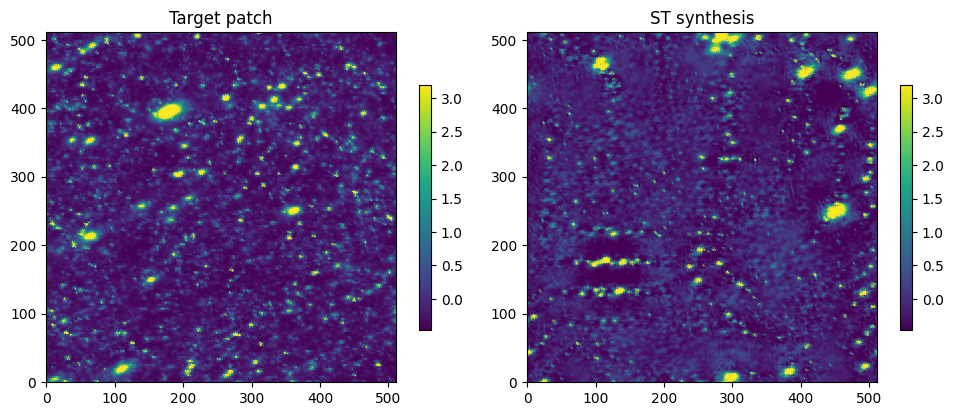

-0.0001843601483321744
1.0550649700295756
1.7128330662345439e-06


In [9]:
plt.figure(figsize=(10,4))
#vmin, vmax = np.nanpercentile(patches[0], [1, 99])
#vmin, vmax = np.nanpercentile(u1.cpu().numpy(), [1, 99])
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
plt.imshow(patch - np.mean(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch")

plt.subplot(1,2,2)
plt.imshow(u1.cpu().numpy() - np.mean(u1.cpu().numpy()), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST synthesis")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patches[0]))

# Log space synthesis 

Lognormalization

In [10]:
#Load the patches 
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis


def load_patches_log(obj):
    """
    Returns np.ndarray of shape (H,W) or (N,H,W)
    """
    if isinstance(obj, np.ndarray):
        return np.asarray(obj)

    if isinstance(obj, str):
        if os.path.isdir(obj):
            patches = []
            for f in sorted(os.listdir(obj)):
                if f.endswith(".npy"):
                    patches.append(np.load(os.path.join(obj, f)))
            if len(patches) == 0:
                raise ValueError(f"No .npy files found in folder: {obj}")
            return np.stack(patches)

        if obj.endswith(".npy"):
            return np.load(obj)

        if obj.endswith(".npz"):
            z = np.load(obj)
            if "patches" not in z:
                raise ValueError(f"{obj} does not contain key 'patches'")
            return z["patches"]

    raise ValueError("Unsupported input type (need ndarray, .npy, .npz, or folder)")
    
#Find the parameters to do the transformation 

def log_transform(x, A, B, eps=1e-9):
    return np.log(A * x + B + eps)


def objective(params, data_flat):
    A, B = params

    if A <= 0:
        return 1e20
    if np.any(A * data_flat + B <= 0):
        return 1e20

    y = log_transform(data_flat, A, B, eps=1e-9)
    return skew(y) ** 2 + kurtosis(y) ** 2


def find_parameters(obj, margin=1.0, method="Nelder-Mead", max_iter=3000, verbose=False):
    """
    obj : ndarray (H,W) or (N,H,W) OR path to .npy/.npz OR folder of .npy
    Returns : A (float), B (float) (globaux)
    """
    patches = load_patches_log(obj).astype(np.float64)

    if patches.ndim == 2:
        data_flat = patches.reshape(-1)
    elif patches.ndim == 3:
        data_flat = patches.reshape(-1)
    else:
        raise ValueError("patches must be (H,W) or (N,H,W)")

    A_init = 1.0
    minx = float(np.min(data_flat))
    B_init = (-A_init * minx) + margin
    if B_init <= 0:
        B_init = margin

    res = minimize(
        objective,
        x0=np.array([A_init, B_init], dtype=np.float64),
        args=(data_flat,),
        method=method,
        options={"maxiter": max_iter, "disp": verbose},
    )

    A_opt, B_opt = map(float, res.x)

    # Pas de fallback : on impose la validité, sinon on lève une erreur
    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")
    if A_opt <= 0:
        raise RuntimeError(f"Invalid A found: A={A_opt} (must be > 0)")
    if np.any(A_opt * data_flat + B_opt <= 0):
        raise RuntimeError(
            "Invalid (A,B): Ax+B <= 0 for some pixels. "
            f"Got A={A_opt}, B={B_opt}. Try increasing margin or changing init/method."
        )

    return A_opt, B_opt

# compute the result patches
def normalize_array(patches, A, B, eps=1e-6):
    """
    y = log(Ax+B+eps), then standardisation (mean/std)
    Mean/std computed globally (on the whole tensor)
    """
    patches = np.asarray(patches, dtype=np.float64)

    if np.any(A * patches + B <= 0):
        raise ValueError("Ax+B must be > 0 everywhere for log-transform.")

    y = np.log(A * patches + B + eps)

    mean = float(y.mean())
    std = float(y.std())
    if std == 0:
        raise ValueError("Std is zero after log-transform; check data / (A,B).")

    y_norm = (y - mean) / std
    return y_norm, mean, std


def denormalize_array(patches_norm, mean, std, A, B, eps=1e-6):
    """
    Inversion:
      y = norm*std + mean
      Ax+B+eps = exp(y)
      x = (exp(y) - eps - B) / A
    """
    patches_norm = np.asarray(patches_norm, dtype=np.float64)
    y = patches_norm * std + mean
    x = (np.exp(y) - eps - B) / A
    return x



# log normalization

def normalize(patch_or_path, eps=1e-6, save_to=None, **find_kwargs):
    patches = load_patches_log(patch_or_path)
    A, B = find_parameters(patches, **find_kwargs)
    patches_norm, mean, std = normalize_array(patches, A, B, eps=eps)

    if save_to is not None:
        if not str(save_to).endswith(".npz"):
            raise ValueError("save_to must be a .npz file path")
        np.savez(save_to, patches=patches_norm, mean=mean, std=std, A=A, B=B)

    return patches_norm, mean, std, A, B


def denormalize(patch_or_path, mean, std, A, B, eps=1e-6, save_to=None):
    patches_norm = load_patches_log(patch_or_path)
    patches = denormalize_array(patches_norm, mean, std, A, B, eps=eps)

    if save_to is not None:
        if not str(save_to).endswith(".npz"):
            raise ValueError("save_to must be a .npz file path")
        np.savez(save_to, patches=patches, mean=mean, std=std, A=A, B=B)

    return patches

In [11]:
patch_log, mean, std, A, B = normalize(patch)

In [12]:
target = patch_log
seed=2
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None

In [13]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=500,
        lr=0.01,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=seed,
    )

Running synthesis on device cuda:0 dtype torch.float64
Initial shape for u: (1, 1, 512, 512)
Synthesis on 5880 ST coefficients
[LBFGS] inner iter 10, loss = 1.117702e+02
[LBFGS] inner iter 20, loss = 4.175120e+01
[LBFGS] inner iter 30, loss = 1.215602e+01
[LBFGS] inner iter 40, loss = 3.377324e+00
[LBFGS] inner iter 50, loss = 5.851496e-01
[LBFGS] inner iter 60, loss = 3.145434e-01
[LBFGS] inner iter 70, loss = 2.777094e-01
[LBFGS] inner iter 80, loss = 1.649140e-01
[LBFGS] inner iter 90, loss = 8.009077e-02
[LBFGS] inner iter 100, loss = 4.810173e-02
[LBFGS] inner iter 110, loss = 2.512174e-02
[LBFGS] inner iter 120, loss = 1.620131e-02
[LBFGS] inner iter 130, loss = 1.241202e-02
[LBFGS] inner iter 140, loss = 9.710702e-03
[LBFGS] inner iter 150, loss = 8.216758e-03
[LBFGS] inner iter 160, loss = 7.124509e-03
[LBFGS] inner iter 170, loss = 5.756314e-03
[LBFGS] inner iter 180, loss = 4.969559e-03
[LBFGS] inner iter 190, loss = 4.335203e-03
[LBFGS] inner iter 200, loss = 3.594147e-03
[L

In [14]:
synth_raw = denormalize(u1.cpu().numpy(), mean, std, A, B)

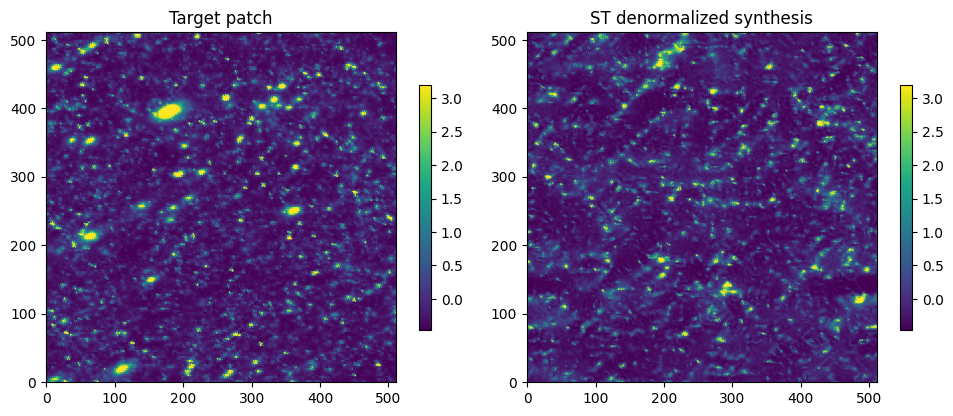

0.0008269207024996046
1.0330169242056708
0.9999999999999999


In [15]:
plt.figure(figsize=(10,4))
vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
plt.imshow(patch, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch")

plt.subplot(1,2,2)
plt.imshow(synth_raw, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST denormalized synthesis")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))

# Analysis 

In [17]:
import os

os.makedirs("data/target", exist_ok=True)
os.makedirs("data/synth", exist_ok=True)


np.save("data/target/patch_0.npy", patch)
np.save("data/synth/synth_0.npy", synth_raw)

configs = [
    {'path': "data/target", 'color': 'black', 'label': 'Original Target'},
    {'path': "data/synth", 'color': 'red', 'label': 'ST Synthesis'}
]


In [20]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from quantimpy import minkowski as mk

#STATS

def power_spectrum(image):
    n = image.shape[0]
    fourier = np.fft.fftn(image)
    amplitude = (np.abs(fourier) ** 2).flatten()
    kfreq = np.fft.fftfreq(n) * n
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = (kfreq2D[0] ** 2 + kfreq2D[1] ** 2).flatten() ** (1 / 2)
    kbins = np.arange(1/2, n // 2 + 1, 1)
    kvals = (kbins[1:] + kbins[:-1]) / 2
    bins, _, _ = stats.binned_statistic(knrm, amplitude, statistic="mean", bins=kbins)
    return kvals, bins

def compute_minkowski(images, thresholds):
    res = {"areas": [], "lengths": [], "eulers": []}
    for image in images:
        a, l, e = [], [], []
        img_arr = np.ascontiguousarray(image)
        for t in thresholds:
            area, length, euler = mk.functionals(np.ascontiguousarray(img_arr > t, dtype=bool))
            a.append(area); l.append(length); e.append(euler)
        res["areas"].append(a); res["lengths"].append(l); res["eulers"].append(e)
    return {k: np.array(v) for k, v in res.items()}

def bispectrum(image):
    n = image.shape[0]
    img_centered = image - np.mean(image)
    
    f1 = np.fft.fftn(img_centered)
    f2 = np.fft.fftn(img_centered**2)
    
    bispec_map = np.real(f1 * np.conj(f2)).flatten()
    
    kfreq = np.fft.fftfreq(n) * n
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = (kfreq2D[0] ** 2 + kfreq2D[1] ** 2).flatten() ** (1 / 2)
    
    kbins = np.arange(1/2, n // 2 + 1, 1)
    kvals = (kbins[1:] + kbins[:-1]) / 2
    
    bins, _, _ = stats.binned_statistic(knrm, bispec_map, statistic="mean", bins=kbins)
    return kvals, bins

# Plot

def plot_pdf(samples, num_bins=50, prange=(-1, 60), yscale="log"):
    plt.figure(figsize=(7, 5))
    for imgs, color, label in samples:
        pdfs = [np.histogram(img.flatten(), bins=num_bins, range=prange, density=True)[0] for img in imgs]
        edges = np.histogram(imgs[0], bins=num_bins, range=prange)[1]
        centers = 0.5 * (edges[:-1] + edges[1:])
        plt.fill_between(centers, np.percentile(pdfs, 16, axis=0), np.percentile(pdfs, 84, axis=0), color=color, alpha=0.2)
        plt.plot(centers, np.mean(pdfs, axis=0), color=color, label=label)
    plt.yscale(yscale); plt.xlabel("Intensité"); plt.ylabel("PDF"); plt.legend(); plt.grid(True, alpha=0.3)

def plot_ps(samples):
    plt.figure(figsize=(7, 5))
    for imgs, color, label in samples:
        sq_imgs = [p for p in imgs if p.shape[0] == p.shape[1]]
        res = [power_spectrum(img) for img in sq_imgs]
        k, ps_data = res[0][0], np.array([r[1] for r in res])
        plt.fill_between(k, np.percentile(ps_data, 16, axis=0), np.percentile(ps_data, 84, axis=0), color=color, alpha=0.2)
        plt.plot(k, np.mean(ps_data, axis=0), color=color, label=label)
    plt.xscale("log"); plt.yscale("log"); plt.xlabel(r"$k$"); plt.ylabel(r"$P(k)$"); plt.legend(); plt.grid(True, alpha=0.3)

def plot_minkowski_plots(samples, thresholds):
    names = [r"$M_0$ (Area)", r"$M_1$ (Perimeter)", r"$M_2$ (Euler)"]
    keys = ["areas", "lengths", "eulers"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for imgs, color, label in samples:
        data = compute_minkowski(imgs, thresholds)
        for i in range(3):
            val = data[keys[i]]
            axes[i].fill_between(thresholds, np.percentile(val, 16, axis=0), np.percentile(val, 84, axis=0), color=color, alpha=0.2)
            axes[i].plot(thresholds, np.mean(val, axis=0), color=color, label=label if i==0 else "")
            axes[i].set_ylabel(names[i]); axes[i].set_xlabel("Threshold"); axes[i].grid(True, alpha=0.3)
    axes[0].legend(); plt.tight_layout()

def plot_bs(samples):
    plt.figure(figsize=(7, 5))
    for imgs, color, label in samples:
        sq_imgs = [p for p in imgs if p.shape[0] == p.shape[1]]
        res = [bispectrum(img) for img in sq_imgs]
        k, bs_data = res[0][0], np.array([r[1] for r in res])
        
        plt.fill_between(k, np.percentile(bs_data, 16, axis=0), np.percentile(bs_data, 84, axis=0), color=color, alpha=0.2)
        plt.plot(k, np.mean(bs_data, axis=0), color=color, label=label)
    
    plt.xscale("log")
    plt.yscale("linear") 
    plt.xlabel(r"$k$"); plt.ylabel(r"$B(k)$"); plt.legend(); plt.grid(True, alpha=0.3)

    
# Analysis

def flexible_analysis(folders, labels=None, colors=None, 
                      pdf_bins=50, pdf_range=(-1, 60), 
                      mf_nbins=30, mf_range=(-2, 5)):
    """
    Statisical analysis of the synthesis and the target
    """
    if labels is None: labels = [os.path.basename(f.rstrip('/')) for f in folders]
    if colors is None: colors = [f"C{i}" for i in range(len(folders))]
    
    samples = []
    for f in folders:
        paths = sorted(glob.glob(os.path.join(f, "*.npy")))
        samples.append([np.load(p) for p in paths])
    
    formatted_samples = list(zip(samples, colors, labels))
    
    plot_pdf(formatted_samples, num_bins=pdf_bins, prange=pdf_range)
    plt.title("PDF")
    plt.show()
    
    plot_ps(formatted_samples)
    plt.title("Power spectrum $P(k)$")
    plt.show()
    
    mf_thresholds = np.linspace(mf_range[0], mf_range[1], mf_nbins)
    plot_minkowski_plots(formatted_samples, mf_thresholds)
    plt.show()
    
    plot_bs(formatted_samples)
    plt.title("Bispectrum $B(k)$ (Non-Gaussianity)")
    plt.show()

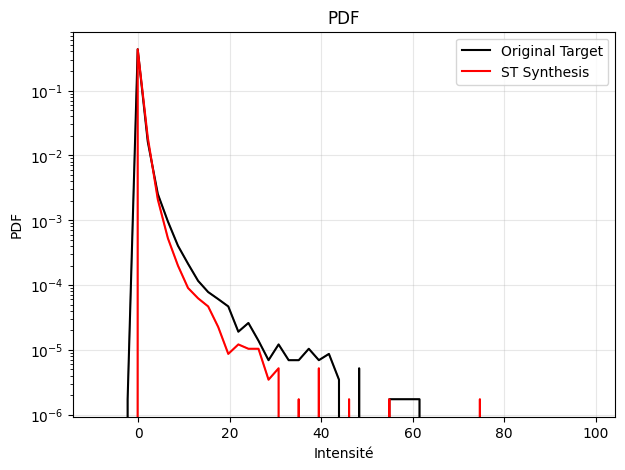

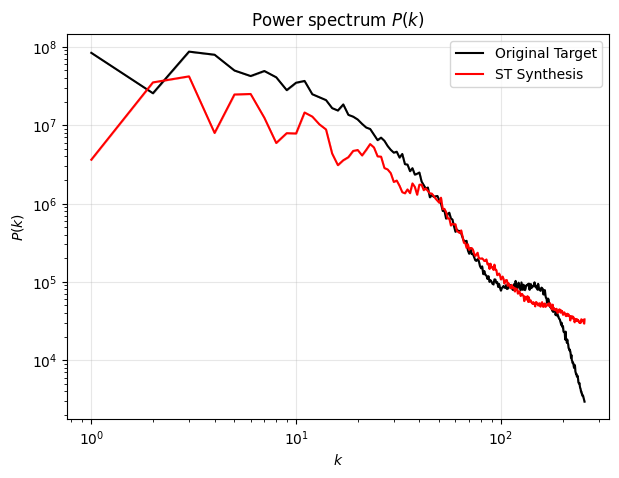

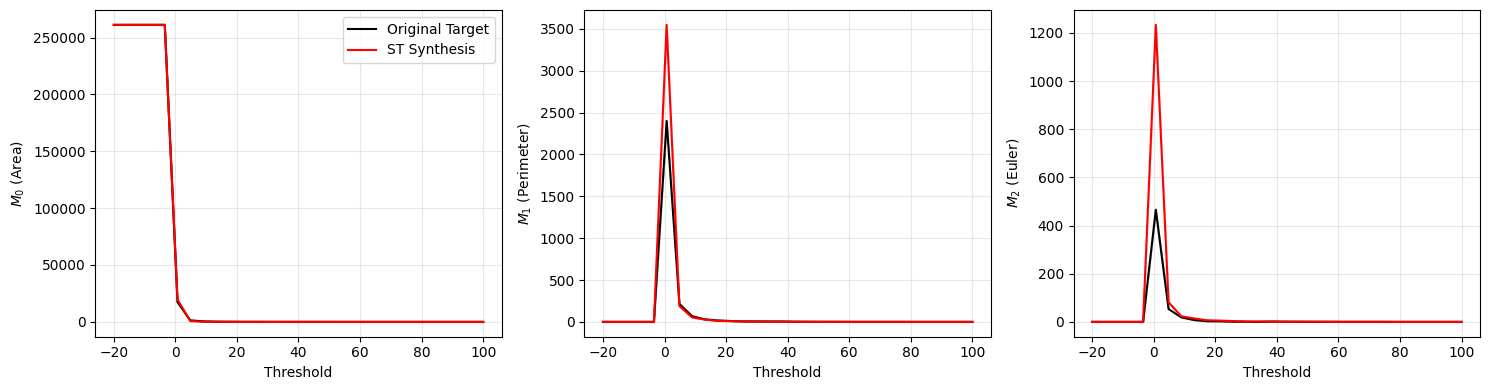

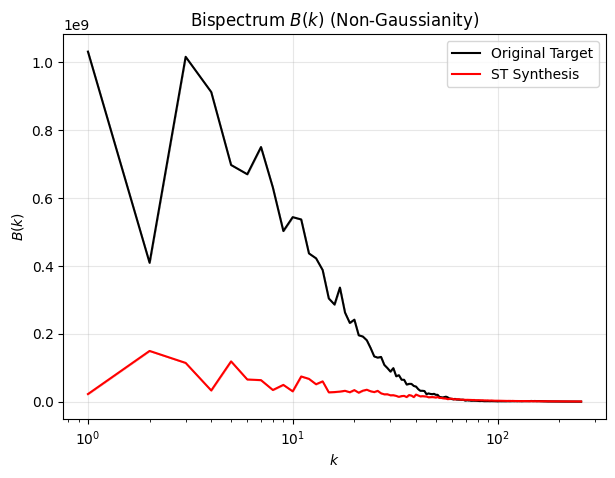

In [21]:
paths = [c['path'] for c in configs]
labels = [c['label'] for c in configs]
colors = [c['color'] for c in configs]

flexible_analysis(
    folders=paths,
    labels=labels,
    colors=colors,
    pdf_range=(-10, 100), 
    mf_range=(-20, 100),
    pdf_bins=50,
    mf_nbins=30
)